In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
import math
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("whr2023.csv")
df.head()
sns.set_theme(style="whitegrid")
sns.set_palette("husl")

In [3]:
df.columns

Index(['Country name', 'iso alpha', 'Regional indicator', 'Happiness score',
       'Standard error of ladder score', 'upperwhisker', 'lowerwhisker',
       'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Ladder score in Dystopia',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

In [4]:
a = df[df.columns[df.columns.str.contains("Explained by:")]]
ndf = df.drop(columns=a)
ndf= ndf.fillna(0)

(array([0., 1., 2., 3., 4., 5., 6., 7., 8.]),
 [Text(0.0, 0, '0'),
  Text(1.0, 0, '1'),
  Text(2.0, 0, '2'),
  Text(3.0, 0, '3'),
  Text(4.0, 0, '4'),
  Text(5.0, 0, '5'),
  Text(6.0, 0, '6'),
  Text(7.0, 0, '7'),
  Text(8.0, 0, '8')])

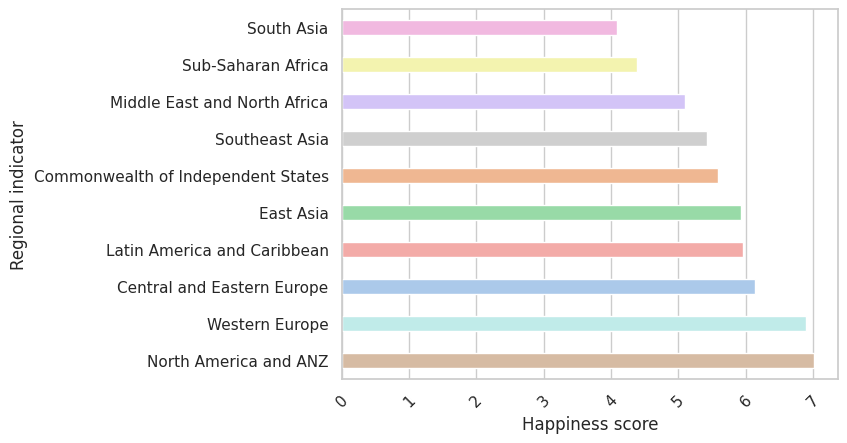

In [5]:
regional_happiness = ndf.groupby("Regional indicator")["Happiness score"].mean()
regional_happiness = regional_happiness.to_frame()

sns.barplot(x="Happiness score", y="Regional indicator", data=regional_happiness,
            label="Happiness Score", hue="Regional indicator", palette="pastel", width=0.4,order=regional_happiness.sort_values("Happiness score").index)
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Bottom 10 Happiest Countries')

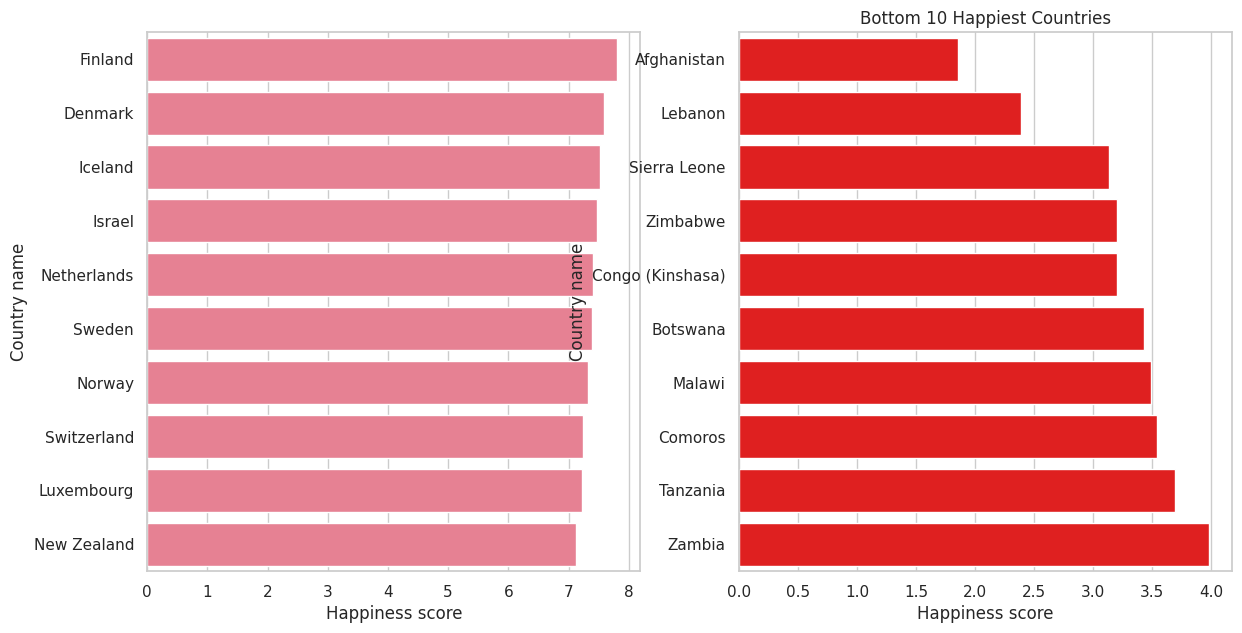

In [6]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

top10 = df.nlargest(10, "Happiness score")
sns.barplot(x="Happiness score", y="Country name", data=top10,ax=ax1)
plt.title("Top 10 Happiest Countries")

bottom10 = df.nsmallest(10, "Happiness score")
sns.barplot(x="Happiness score", y="Country name",
            data=bottom10,color="red", ax=ax2)


plt.title("Bottom 10 Happiest Countries")

<Axes: xlabel='Happiness score', ylabel='Count'>

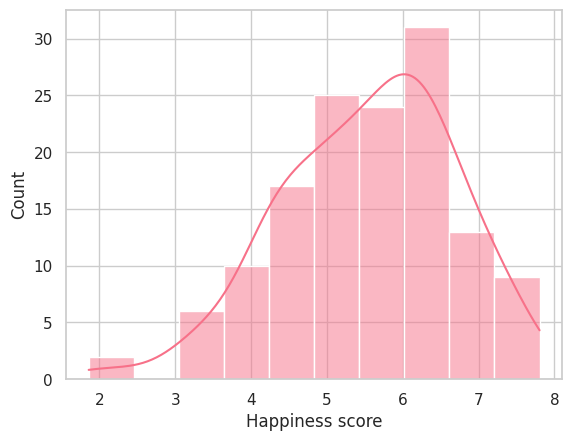

In [7]:
sns.histplot(df["Happiness score"], kde=True)

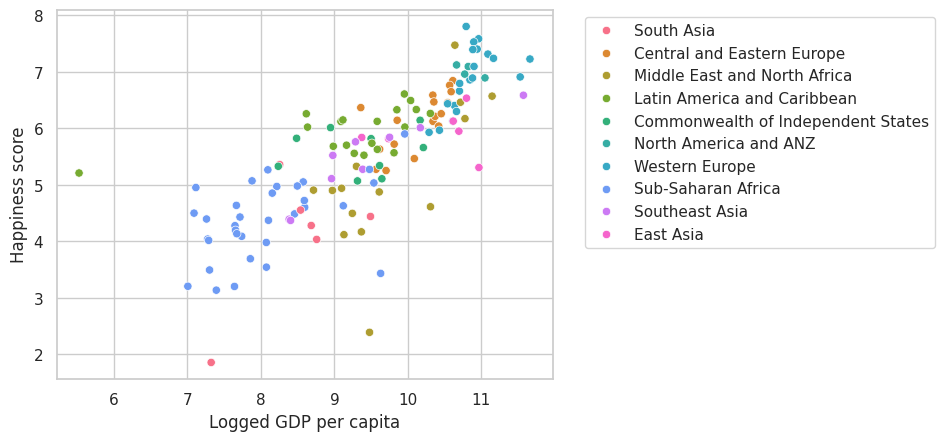

In [8]:
sns.scatterplot(x="Logged GDP per capita", y="Happiness score",
                hue="Regional indicator", data=df)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

<Axes: xlabel='Logged GDP per capita', ylabel='Happiness score'>

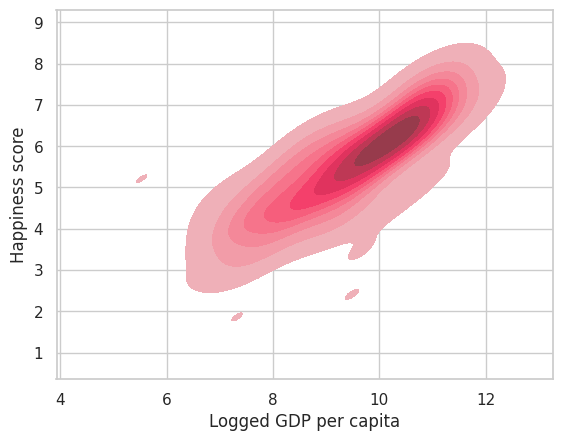

In [9]:
sns.kdeplot(x="Logged GDP per capita", y="Happiness score",
            data=df, fill=True)

In [10]:
df.head()

,Country name,iso alpha,Regional indicator,Happiness score,Standard error of ladder score,upperwhisker,lowerwhisker,Logged GDP per capita,Social support,Healthy life expectancy,...,Generosity,Perceptions of corruption,Ladder score in Dystopia,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Afghanistan,AFG,South Asia,1.859,0.033,1.923,1.795,7.324,0.341,54.712,...,-0.081,0.847,1.778,0.645,0.000,0.087,0.000,0.093,0.059,0.976
1,Albania,ALB,Central and Eastern Europe,5.277,0.066,5.406,5.148,9.567,0.718,69.150,...,-0.007,0.878,1.778,1.449,0.951,0.480,0.549,0.133,0.037,1.678
2,Algeria,DZA,Middle East and North Africa,5.329,0.062,5.451,5.207,9.300,0.855,66.549,...,-0.117,0.717,1.778,1.353,1.298,0.409,0.252,0.073,0.152,1.791
3,Argentina,ARG,Latin America and Caribbean,6.024,0.063,6.147,5.900,9.959,0.891,67.200,...,-0.089,0.814,1.778,1.590,1.388,0.427,0.587,0.088,0.082,1.861
4,Armenia,ARM,Commonwealth of Independent States,5.342,0.066,5.470,5.213,9.615,0.790,67.789,...,-0.155,0.705,1.778,1.466,1.134,0.443,0.551,0.053,0.160,1.534


<Axes: >

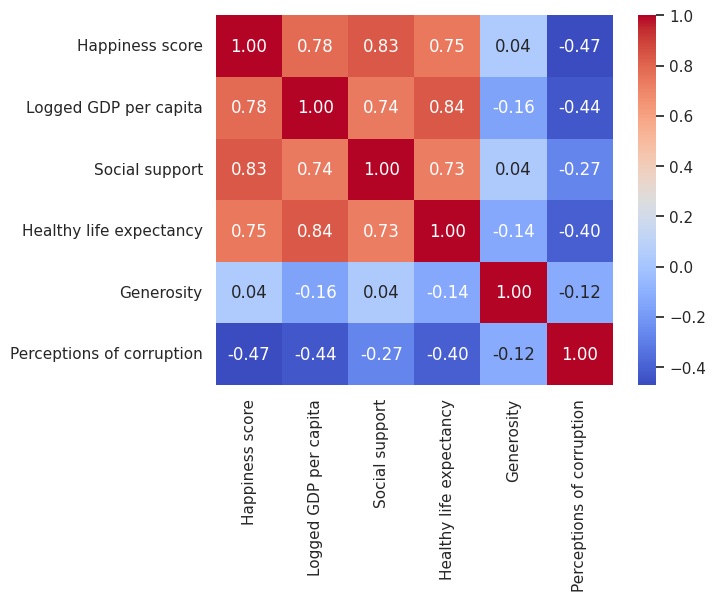

In [33]:
cols = ["Happiness score", "Logged GDP per capita",
        "Social support", "Healthy life expectancy","Generosity","Perceptions of corruption"]
corr = df[cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

In [20]:
# What is the average happiness score globally?
# Confidince interval using t-test

n = 30
sample = df.sample(n=n)
sample_mean = sample["Happiness score"].mean()
sample_std = sample["Happiness score"].std()
t = abs(stats.t.ppf(0.05/2, n-1))

def compute_confidence_interval(mean_x,std_x,t,n):
  h = mean_x + t * (std_x / math.sqrt(n))
  l = mean_x - t * (std_x / math.sqrt(n))
  print(h,l)


compute_confidence_interval(sample_mean, sample_std, t, n)

6.231035393224036 5.482431273442633


In [53]:
# Does GDP predict happiness?
x_train,x_test,y_train,y_test = train_test_split(df["Logged GDP per capita"],df["Happiness score"],test_size=1/4)
model = LinearRegression()
model.fit(x_train.to_frame(),y_train.to_frame())
s= model.score(x_test.to_frame(),y_test.to_frame())
print("r^2: %.3f" % s)
print("r: %.3f" % math.sqrt(s))

r^2: 0.721
r: 0.849


[[0.72465947]]
[-1.32698135]


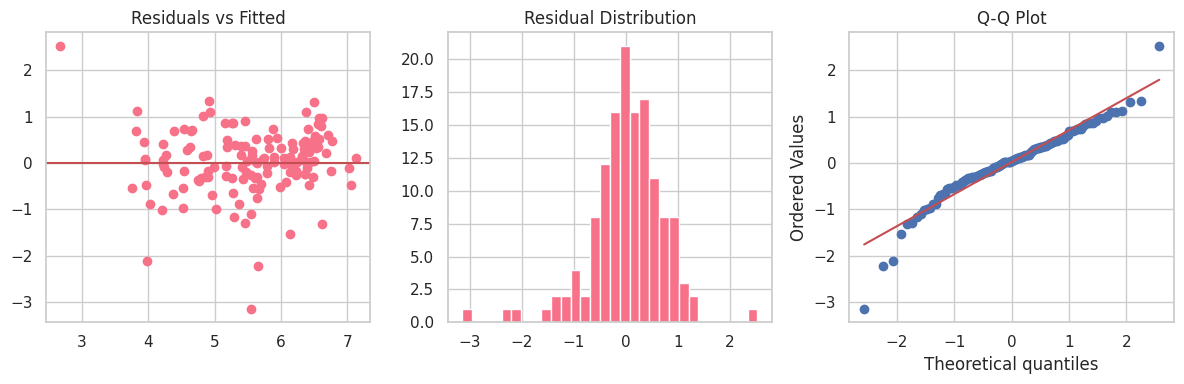

In [58]:
predicted = model.coef_[0] * df["Logged GDP per capita"] + model.intercept_[0]
residuals =  df["Happiness score"] - predicted

# Plot 1: Residuals vs Fitted
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(predicted, residuals)
plt.axhline(y=0, color='r')
plt.title("Residuals vs Fitted")

# Plot 2: Histogram
plt.subplot(1,3,2)
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")

# Plot 3: Q-Q Plot
plt.subplot(1,3,3)
stats.probplot(residuals, plot=plt)
plt.title("Q-Q Plot")

plt.tight_layout()
plt.show()

In [65]:
# Is the relationship linear or curved?
cols = ["Logged GDP per capita",
        "Social support", "Healthy life expectancy","Generosity","Perceptions of corruption"]

x_train,x_test,y_train,y_test = train_test_split(df[cols],df["Happiness score"],test_size=1/3)
x_train =x_train.fillna(0)
x_test = x_test.fillna(0)
model = LinearRegression()
model.fit(x_train,y_train.to_frame())
s= model.score(x_test,y_test.to_frame())
print("r^2: %.3f" % s)
print("r: %.3f" % math.sqrt(s))


r^2: 0.756
r: 0.870


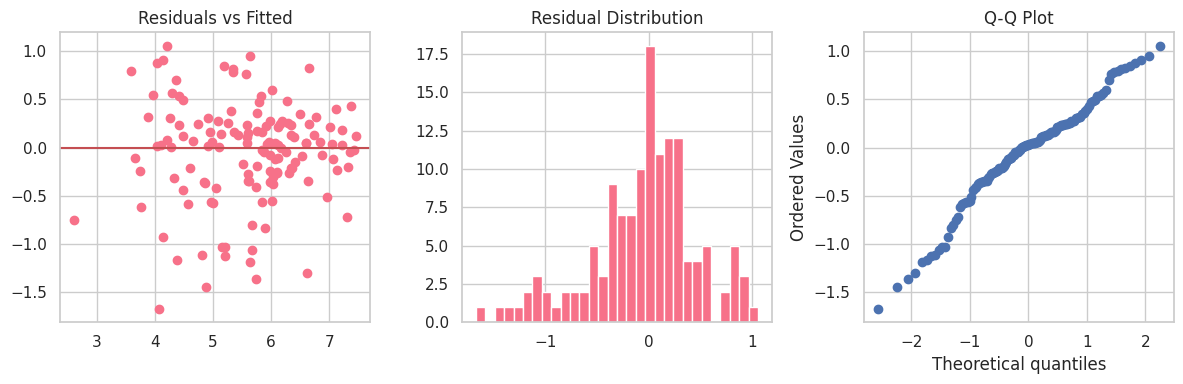

In [68]:
predicted = (
    model.coef_[0][0] * df["Logged GDP per capita"] +
    model.coef_[0][1] * df["Social support"] +
    model.coef_[0][2] * df["Healthy life expectancy"] +
    model.coef_[0][3] * df["Generosity"] +
    model.coef_[0][4] * df["Perceptions of corruption"] +
    model.intercept_[0]
)
residuals =  df["Happiness score"] - predicted

# Plot 1: Residuals vs Fitted
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(predicted, residuals)
plt.axhline(y=0, color='r')
plt.title("Residuals vs Fitted")

# Plot 2: Histogram
plt.subplot(1,3,2)
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")

# Plot 3: Q-Q Plot
plt.subplot(1,3,3)
stats.probplot(residuals, plot=plt)
plt.title("Q-Q Plot")

plt.tight_layout()
plt.show()
